In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

In [2]:
df= pd.read_csv("loan_approval_data.csv")

In [3]:
df.head()
df.info()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 20 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Applicant_ID        950 non-null    float64
 1   Applicant_Income    950 non-null    float64
 2   Coapplicant_Income  950 non-null    float64
 3   Employment_Status   950 non-null    object 
 4   Age                 950 non-null    float64
 5   Marital_Status      950 non-null    object 
 6   Dependents          950 non-null    float64
 7   Credit_Score        950 non-null    float64
 8   Existing_Loans      950 non-null    float64
 9   DTI_Ratio           950 non-null    float64
 10  Savings             950 non-null    float64
 11  Collateral_Value    950 non-null    float64
 12  Loan_Amount         950 non-null    float64
 13  Loan_Term           950 non-null    float64
 14  Loan_Purpose        950 non-null    object 
 15  Property_Area       950 non-null    object 
 16  Educati

Applicant_ID          50
Applicant_Income      50
Coapplicant_Income    50
Employment_Status     50
Age                   50
Marital_Status        50
Dependents            50
Credit_Score          50
Existing_Loans        50
DTI_Ratio             50
Savings               50
Collateral_Value      50
Loan_Amount           50
Loan_Term             50
Loan_Purpose          50
Property_Area         50
Education_Level       50
Gender                50
Employer_Category     50
Loan_Approved         50
dtype: int64

 # Handle missing values

In [4]:
categorical_cols= df.select_dtypes(include=["object"]).columns
numerical_cols= df.select_dtypes(include=["number"]).columns#we can use number as a d_type if there are many types of numberical data like float,int..

In [5]:
from sklearn.impute import SimpleImputer

num_imp= SimpleImputer(strategy='mean')
df[numerical_cols]= num_imp.fit_transform(df[numerical_cols])

In [6]:
cat_imp= SimpleImputer(strategy='most_frequent')
df[categorical_cols]= cat_imp.fit_transform(df[categorical_cols])

In [7]:
df.head()
df.isnull().sum()

Applicant_ID          0
Applicant_Income      0
Coapplicant_Income    0
Employment_Status     0
Age                   0
Marital_Status        0
Dependents            0
Credit_Score          0
Existing_Loans        0
DTI_Ratio             0
Savings               0
Collateral_Value      0
Loan_Amount           0
Loan_Term             0
Loan_Purpose          0
Property_Area         0
Education_Level       0
Gender                0
Employer_Category     0
Loan_Approved         0
dtype: int64

# Exploratory Data Analysis(EDA)

Text(0.5, 1.0, 'Loan approved Data ↓')

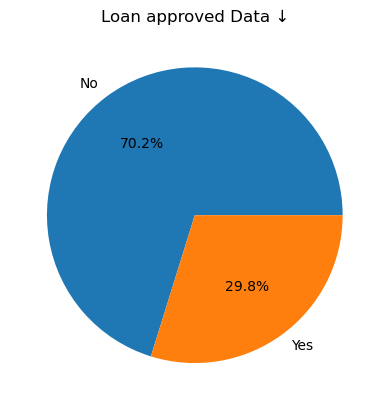

In [8]:
#checking balanced classes

classes_count= df["Loan_Approved"].value_counts()

plt.pie(classes_count, labels=["No", "Yes"], autopct="%1.1f%%")
plt.title("Loan approved Data ↓")

[Text(0, 0, '722'), Text(0, 0, '278')]

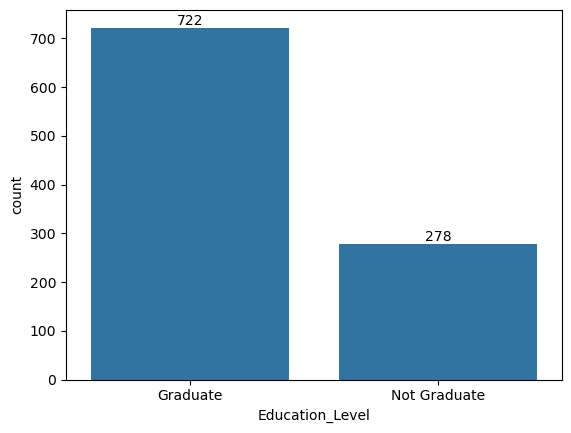

In [9]:
#category base count

# gender_count= df["Gender"].value_counts()
# ax=sns.barplot(gender_count)
# ax.bar_label(ax.containers[0])

edu_count= df["Education_Level"].value_counts()
ax=sns.barplot(edu_count)
ax.bar_label(ax.containers[0])


<Axes: xlabel='Applicant_Income', ylabel='Count'>

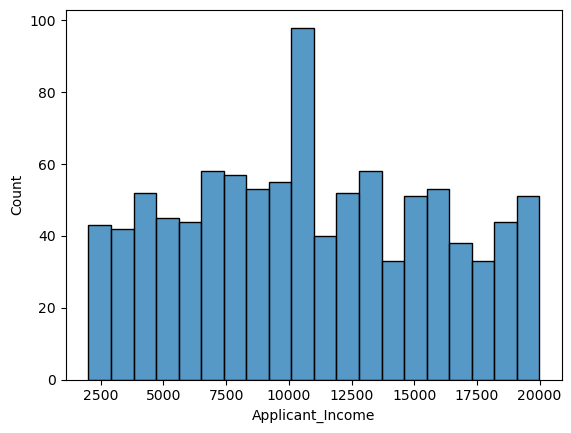

In [10]:
# income analysis

sns.histplot(
    data= df,
    x= "Applicant_Income",
    bins= 20
)

<Axes: xlabel='Coapplicant_Income', ylabel='Count'>

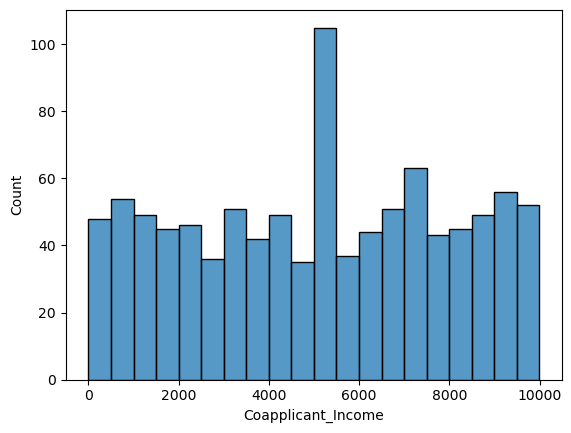

In [11]:
# co-applicant income
sns.histplot(
    data= df,
    x= "Coapplicant_Income",
    bins= 20
)

<Axes: xlabel='Loan_Approved', ylabel='Applicant_Income'>

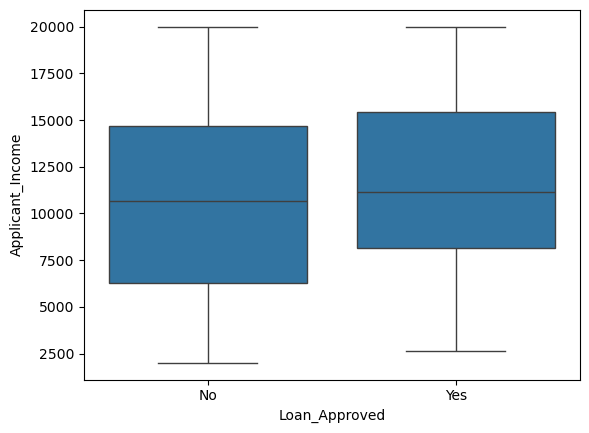

In [12]:
# outliers- box_plots

sns.boxplot(
    data= df,
    x= "Loan_Approved",
    y="Applicant_Income"
)

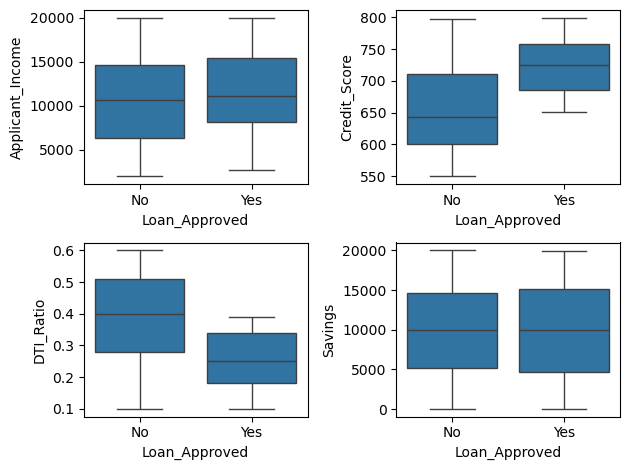

In [13]:
fig,axes= plt.subplots(2,2)

sns.boxplot(ax=axes[0,0], data= df,x= "Loan_Approved",y="Applicant_Income")
sns.boxplot(ax=axes[0,1], data= df,x= "Loan_Approved",y="Credit_Score")
sns.boxplot(ax=axes[1,0], data= df,x= "Loan_Approved",y="DTI_Ratio")
sns.boxplot(ax=axes[1,1], data= df,x= "Loan_Approved",y="Savings")

plt.tight_layout()

<Axes: xlabel='Credit_Score', ylabel='Count'>

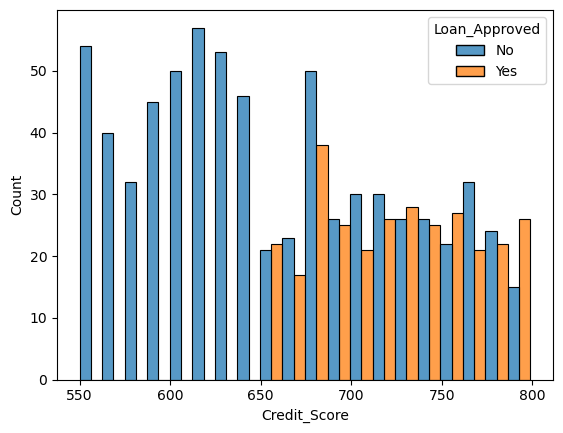

In [14]:
#credit score with loan approved

sns.histplot(
    data=df,
    hue="Loan_Approved",
    x="Credit_Score",
    bins=20,
    multiple="dodge"
)

<Axes: xlabel='Applicant_Income', ylabel='Count'>

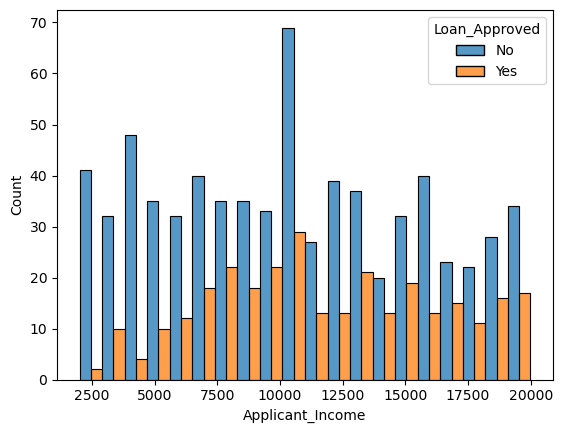

In [15]:
sns.histplot(
    data=df,
    hue="Loan_Approved",
    x="Applicant_Income",
    bins=20,
    multiple="dodge"
)

In [16]:
#Removing Applicant Id
df= df.drop("Applicant_ID", axis=1)

In [17]:
df.head()

,Applicant_Income,Coapplicant_Income,Employment_Status,Age,Marital_Status,Dependents,Credit_Score,Existing_Loans,DTI_Ratio,Savings,Collateral_Value,Loan_Amount,Loan_Term,Loan_Purpose,Property_Area,Education_Level,Gender,Employer_Category,Loan_Approved
0,17795.0,1387.0,Salaried,51.0,Married,0.0,637.0,4.0,0.53,19403.0,45638.0,16619.0,84.0,Personal,Urban,Not Graduate,Female,Private,No
1,2860.0,2679.0,Salaried,46.0,Married,3.0,621.0,2.0,0.30,2580.0,49272.0,38687.0,48.0,Car,Semiurban,Graduate,Male,Private,No
2,7390.0,2106.0,Salaried,25.0,Single,2.0,674.0,4.0,0.20,13844.0,6908.0,27943.0,72.0,Business,Urban,Graduate,Female,Government,Yes
3,13964.0,8173.0,Salaried,40.0,Married,2.0,579.0,3.0,0.31,9553.0,10844.0,27819.0,60.0,Business,Rural,Graduate,Female,Government,No
4,13284.0,4223.0,Self-employed,31.0,Single,2.0,721.0,1.0,0.29,9386.0,37629.0,12741.0,72.0,Car,Urban,Graduate,Male,Private,Yes


# Feature Encoding

In [18]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 19 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Applicant_Income    1000 non-null   float64
 1   Coapplicant_Income  1000 non-null   float64
 2   Employment_Status   1000 non-null   object 
 3   Age                 1000 non-null   float64
 4   Marital_Status      1000 non-null   object 
 5   Dependents          1000 non-null   float64
 6   Credit_Score        1000 non-null   float64
 7   Existing_Loans      1000 non-null   float64
 8   DTI_Ratio           1000 non-null   float64
 9   Savings             1000 non-null   float64
 10  Collateral_Value    1000 non-null   float64
 11  Loan_Amount         1000 non-null   float64
 12  Loan_Term           1000 non-null   float64
 13  Loan_Purpose        1000 non-null   object 
 14  Property_Area       1000 non-null   object 
 15  Education_Level     1000 non-null   object 
 16  Gender 

In [19]:
from sklearn.preprocessing import LabelEncoder, OneHotEncoder

le= LabelEncoder()
df["Education_Level"]= le.fit_transform(df["Education_Level"])
df["Loan_Approved"]= le.fit_transform(df["Loan_Approved"])

In [20]:
df.head()

,Applicant_Income,Coapplicant_Income,Employment_Status,Age,Marital_Status,Dependents,Credit_Score,Existing_Loans,DTI_Ratio,Savings,Collateral_Value,Loan_Amount,Loan_Term,Loan_Purpose,Property_Area,Education_Level,Gender,Employer_Category,Loan_Approved
0,17795.0,1387.0,Salaried,51.0,Married,0.0,637.0,4.0,0.53,19403.0,45638.0,16619.0,84.0,Personal,Urban,1,Female,Private,0
1,2860.0,2679.0,Salaried,46.0,Married,3.0,621.0,2.0,0.30,2580.0,49272.0,38687.0,48.0,Car,Semiurban,0,Male,Private,0
2,7390.0,2106.0,Salaried,25.0,Single,2.0,674.0,4.0,0.20,13844.0,6908.0,27943.0,72.0,Business,Urban,0,Female,Government,1
3,13964.0,8173.0,Salaried,40.0,Married,2.0,579.0,3.0,0.31,9553.0,10844.0,27819.0,60.0,Business,Rural,0,Female,Government,0
4,13284.0,4223.0,Self-employed,31.0,Single,2.0,721.0,1.0,0.29,9386.0,37629.0,12741.0,72.0,Car,Urban,0,Male,Private,1


In [21]:
cols=["Employment_Status","Marital_Status","Employer_Category","Loan_Purpose","Property_Area","Gender"]

ohe= OneHotEncoder(drop="first", sparse_output=False, handle_unknown="ignore")

encoded= ohe.fit_transform(df[cols])

encoded_df= pd.DataFrame(encoded, columns= ohe.get_feature_names_out(cols), index= df.index)

df= pd.concat([df.drop(columns=cols), encoded_df], axis=1)

In [22]:
df.head()
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 28 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   Applicant_Income                 1000 non-null   float64
 1   Coapplicant_Income               1000 non-null   float64
 2   Age                              1000 non-null   float64
 3   Dependents                       1000 non-null   float64
 4   Credit_Score                     1000 non-null   float64
 5   Existing_Loans                   1000 non-null   float64
 6   DTI_Ratio                        1000 non-null   float64
 7   Savings                          1000 non-null   float64
 8   Collateral_Value                 1000 non-null   float64
 9   Loan_Amount                      1000 non-null   float64
 10  Loan_Term                        1000 non-null   float64
 11  Education_Level                  1000 non-null   int64  
 12  Loan_Approved        

# Correlation Heatmap

<Axes: >

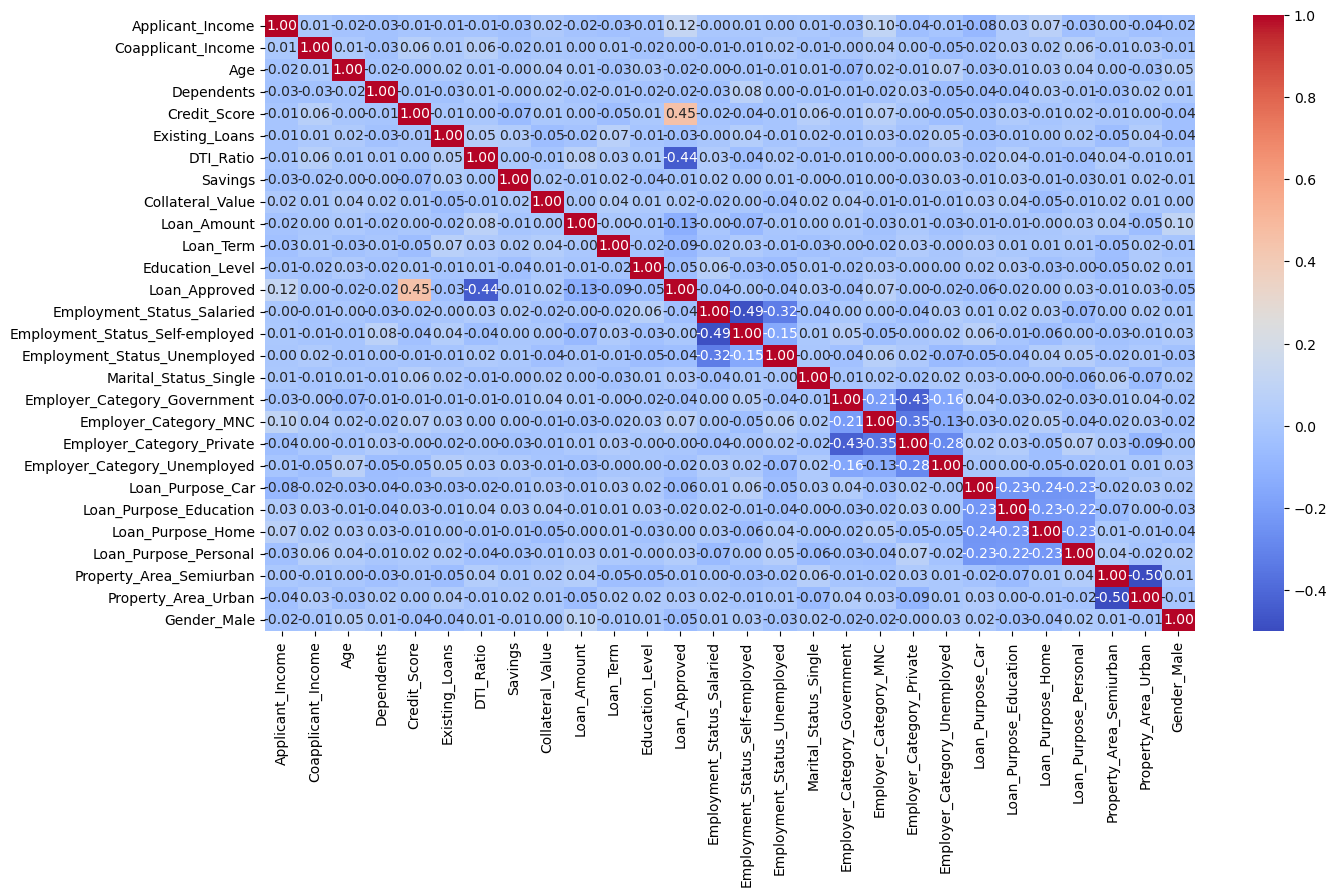

In [23]:
num_cols= df.select_dtypes(include="number")
corr_matrix= num_cols.corr()

plt.figure(figsize=(15,8))
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm"
)

# Train-Test-split + Feature Scaling

In [24]:
X= df.drop("Loan_Approved", axis=1)
y= df["Loan_Approved"]

In [25]:
y.head()

0    0
1    0
2    1
3    0
4    1
Name: Loan_Approved, dtype: int64

In [26]:
X_train, X_test, y_train, y_test= train_test_split(X, y, test_size= 0.2, random_state=42)

In [27]:
from sklearn.preprocessing import StandardScaler

scaler= StandardScaler()

X_train_scaled= scaler.fit_transform(X_train)
X_test_scaled= scaler.transform(X_test)

In [28]:
X_test_scaled

array([[ 0.42610546,  0.55091079,  1.19037073, ...,  2.081666  ,
        -1.05395348,  0.77253245],
       [ 1.00971366,  0.58995935,  0.18392964, ..., -0.48038446,
        -1.05395348,  0.77253245],
       [-0.67557096, -0.54558674,  1.09887608, ..., -0.48038446,
        -1.05395348, -1.29444401],
       ...,
       [-0.67980585, -0.10106072,  1.28186537, ..., -0.48038446,
        -1.05395348, -1.29444401],
       [-0.37650705, -0.97825874, -0.54802752, ..., -0.48038446,
        -1.05395348,  0.77253245],
       [-0.73647272, -1.24497436,  0.73289751, ..., -0.48038446,
        -1.05395348,  0.77253245]], shape=(200, 27))

# Train & Evaluate Models

In [29]:
# Logistic Regression

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score
log_model= LogisticRegression()
log_model.fit(X_train_scaled, y_train)

y_pred=log_model.predict(X_test_scaled)

#Evaluation

print("Precision: ", precision_score(y_test, y_pred))
print("Recall: ", recall_score(y_test, y_pred))
print("F1_score: ", f1_score(y_test, y_pred))
print("Accuracy: ", accuracy_score(y_test, y_pred))
print("CM: ", confusion_matrix(y_test, y_pred))

Precision:  0.7833333333333333
Recall:  0.7704918032786885
F1_score:  0.7768595041322314
Accuracy:  0.865
CM:  [[126  13]
 [ 14  47]]


In [30]:
# KNN

from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score
knn_model= KNeighborsClassifier(n_neighbors=5)
knn_model.fit(X_train_scaled, y_train)

y_pred=knn_model.predict(X_test_scaled)

#Evaluation

print("Precision: ", precision_score(y_test, y_pred))
print("Recall: ", recall_score(y_test, y_pred))
print("F1_score: ", f1_score(y_test, y_pred))
print("Accuracy: ", accuracy_score(y_test, y_pred))
print("CM: ", confusion_matrix(y_test, y_pred))

Precision:  0.6274509803921569
Recall:  0.5245901639344263
F1_score:  0.5714285714285714
Accuracy:  0.76
CM:  [[120  19]
 [ 29  32]]


In [31]:
# Naive Bayes

from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score
nb_model= GaussianNB()
nb_model.fit(X_train_scaled, y_train)

y_pred=nb_model.predict(X_test_scaled)

#Evaluation

print("Precision: ", precision_score(y_test, y_pred))
print("Recall: ", recall_score(y_test, y_pred))
print("F1_score: ", f1_score(y_test, y_pred))
print("Accuracy: ", accuracy_score(y_test, y_pred))
print("CM: ", confusion_matrix(y_test, y_pred))

Precision:  0.8035714285714286
Recall:  0.7377049180327869
F1_score:  0.7692307692307693
Accuracy:  0.865
CM:  [[128  11]
 [ 16  45]]


# Best Model on the basis of Precision=> Naive Bayes

# Feature Engineering

In [32]:
# Adding and Transforming Features

df["DTI_Ratio_sq"]= df["DTI_Ratio"] **2
df["Credit_Score_sq"]= df["Credit_Score"] **2

# df["Applicant_Income_log"]= np.log1p(df["Applicant_Income"])# compresses the Skewed data which gives more accurate results

X=df.drop(columns=["Loan_Approved", "Credit_Score","DTI_Ratio"])
y=df["Loan_Approved"]

#train-test_split
X_train, X_test, y_train, y_test= train_test_split(X, y, test_size= 0.2, random_state=42)

#scaling

scaler= StandardScaler()

X_train_scaled= scaler.fit_transform(X_train)
X_test_scaled= scaler.transform(X_test)

In [33]:
X_train.head()

,Applicant_Income,Coapplicant_Income,Age,Dependents,Existing_Loans,Savings,Collateral_Value,Loan_Amount,Loan_Term,Education_Level,...,Employer_Category_Unemployed,Loan_Purpose_Car,Loan_Purpose_Education,Loan_Purpose_Home,Loan_Purpose_Personal,Property_Area_Semiurban,Property_Area_Urban,Gender_Male,DTI_Ratio_sq,Credit_Score_sq
29,5890.000000,8041.0,31.000000,0.0,0.000000,11906.0,8150.000000,29287.000000,12.0,1,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0121,363609.000000
535,4779.000000,529.0,50.000000,0.0,0.000000,5369.0,5430.000000,14786.000000,72.0,1,...,0.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0441,376996.000000
695,10852.571579,8927.0,36.000000,0.0,4.000000,3186.0,24802.792632,20522.825263,48.0,1,...,0.0,0.0,0.0,0.0,1.0,1.0,0.0,1.0,0.0484,341056.000000
557,2384.000000,2113.0,39.971579,1.0,4.000000,11882.0,48542.000000,13312.000000,24.0,0,...,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.1156,527076.000000
836,5228.000000,5249.0,42.000000,1.0,1.950526,17669.0,24802.792632,13906.000000,84.0,0,...,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0324,457021.542187


In [34]:
# Logistic Regression

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score
log_model= LogisticRegression()
log_model.fit(X_train_scaled, y_train)

y_pred=log_model.predict(X_test_scaled)

#Evaluation

print("Precision: ", precision_score(y_test, y_pred))
print("Recall: ", recall_score(y_test, y_pred))
print("F1_score: ", f1_score(y_test, y_pred))
print("Accuracy: ", accuracy_score(y_test, y_pred))
print("CM: ", confusion_matrix(y_test, y_pred))

Precision:  0.7903225806451613
Recall:  0.8032786885245902
F1_score:  0.7967479674796748
Accuracy:  0.875
CM:  [[126  13]
 [ 12  49]]


In [35]:
# KNN

from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score
knn_model= KNeighborsClassifier(n_neighbors=5)
knn_model.fit(X_train_scaled, y_train)

y_pred=knn_model.predict(X_test_scaled)

#Evaluation

print("Precision: ", precision_score(y_test, y_pred))
print("Recall: ", recall_score(y_test, y_pred))
print("F1_score: ", f1_score(y_test, y_pred))
print("Accuracy: ", accuracy_score(y_test, y_pred))
print("CM: ", confusion_matrix(y_test, y_pred))

Precision:  0.62
Recall:  0.5081967213114754
F1_score:  0.5585585585585585
Accuracy:  0.755
CM:  [[120  19]
 [ 30  31]]


In [36]:
# Naive Bayes

from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score
nb_model= GaussianNB()
nb_model.fit(X_train_scaled, y_train)

y_pred=nb_model.predict(X_test_scaled)

#Evaluation

print("Precision: ", precision_score(y_test, y_pred))
print("Recall: ", recall_score(y_test, y_pred))
print("F1_score: ", f1_score(y_test, y_pred))
print("Accuracy: ", accuracy_score(y_test, y_pred))
print("CM: ", confusion_matrix(y_test, y_pred))

Precision:  0.7833333333333333
Recall:  0.7704918032786885
F1_score:  0.7768595041322314
Accuracy:  0.865
CM:  [[126  13]
 [ 14  47]]


In [39]:
import joblib

# Bilkul fresh pkl files save karein bina kisi confusion ke
joblib.dump(log_model, "loan_model.pkl")
joblib.dump(scaler, "scaler.pkl")
joblib.dump(ohe, "ohe.pkl")

# Check karne ke liye ki aapke model ko kaunse columns chahiye, is line ka output dekho:
print("Aapke model ke columns ka sahi order yeh hai:")
print(list(X.columns))

Aapke model ke columns ka sahi order yeh hai:
['Applicant_Income', 'Coapplicant_Income', 'Age', 'Dependents', 'Existing_Loans', 'Savings', 'Collateral_Value', 'Loan_Amount', 'Loan_Term', 'Education_Level', 'Employment_Status_Salaried', 'Employment_Status_Self-employed', 'Employment_Status_Unemployed', 'Marital_Status_Single', 'Employer_Category_Government', 'Employer_Category_MNC', 'Employer_Category_Private', 'Employer_Category_Unemployed', 'Loan_Purpose_Car', 'Loan_Purpose_Education', 'Loan_Purpose_Home', 'Loan_Purpose_Personal', 'Property_Area_Semiurban', 'Property_Area_Urban', 'Gender_Male', 'DTI_Ratio_sq', 'Credit_Score_sq']
